# E-Commerce Sales Dashboard
### Analysing 96,478 orders and R$13.2M in revenue from Olist (2016–2018)

**Tools:** Python · Pandas · Matplotlib · Seaborn  
**Dataset:** [Brazilian E-Commerce by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Author:** Mohnish | [GitHub](https://github.com/Incrust-1)

In [3]:
import pandas as pd

orders = pd.read_csv('data/olist_orders_dataset.csv')
items  = pd.read_csv('data/olist_order_items_dataset.csv')

print("Orders shape:", orders.shape)
print("Items shape:", items.shape)
print("\nOrders columns:", list(orders.columns))

Orders shape: (99441, 8)
Items shape: (112650, 7)

Orders columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [6]:
orders.shape

(99441, 8)

In [7]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [8]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("Done! New dtypes:")
print(orders[date_cols].dtypes)

Done! New dtypes:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [9]:
orders['year']  = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month
orders['month_name'] = orders['order_purchase_timestamp'].dt.strftime('%b %Y')

print(orders[['order_purchase_timestamp', 'year', 'month', 'month_name']].head())

  order_purchase_timestamp  year  month month_name
0      2017-10-02 10:56:33  2017     10   Oct 2017
1      2018-07-24 20:41:37  2018      7   Jul 2018
2      2018-08-08 08:38:49  2018      8   Aug 2018
3      2017-11-18 19:28:06  2017     11   Nov 2017
4      2018-02-13 21:18:39  2018      2   Feb 2018


In [10]:
print("Order statuses:\n", orders['order_status'].value_counts())

orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f"\nDelivered orders: {len(orders_delivered)} out of {len(orders)}")

Order statuses:
 order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Delivered orders: 96478 out of 99441


In [11]:
items = pd.read_csv('data/olist_order_items_dataset.csv')
print(items.head())
print("\nItems columns:", list(items.columns))

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  2018-08-15 10:10:18   12.99          12.7

In [12]:
df = orders_delivered.merge(items, on='order_id', how='inner')
print("Merged shape:", df.shape)
print("Columns:", list(df.columns))

Merged shape: (110197, 17)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'year', 'month', 'month_name', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


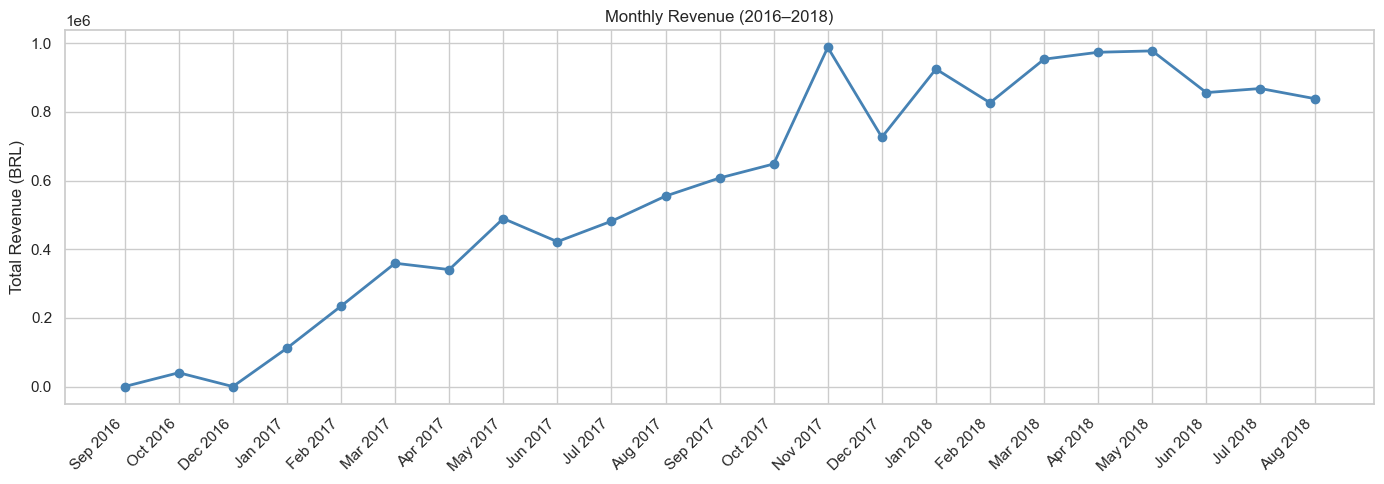

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

monthly = df.groupby('month_name')['price'].sum().reset_index()
monthly['order_date'] = pd.to_datetime(monthly['month_name'], format='%b %Y')
monthly = monthly.sort_values('order_date')

plt.figure(figsize=(14, 5))
plt.plot(monthly['month_name'], monthly['price'], marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue (2016–2018)')
plt.ylabel('Total Revenue (BRL)')
plt.xlabel('')
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()

In [14]:
products   = pd.read_csv('data/olist_products_dataset.csv')
category   = pd.read_csv('data/product_category_name_translation.csv')

products = products.merge(category, on='product_category_name', how='left')
df2 = df.merge(products[['product_id','product_category_name_english']], on='product_id', how='left')

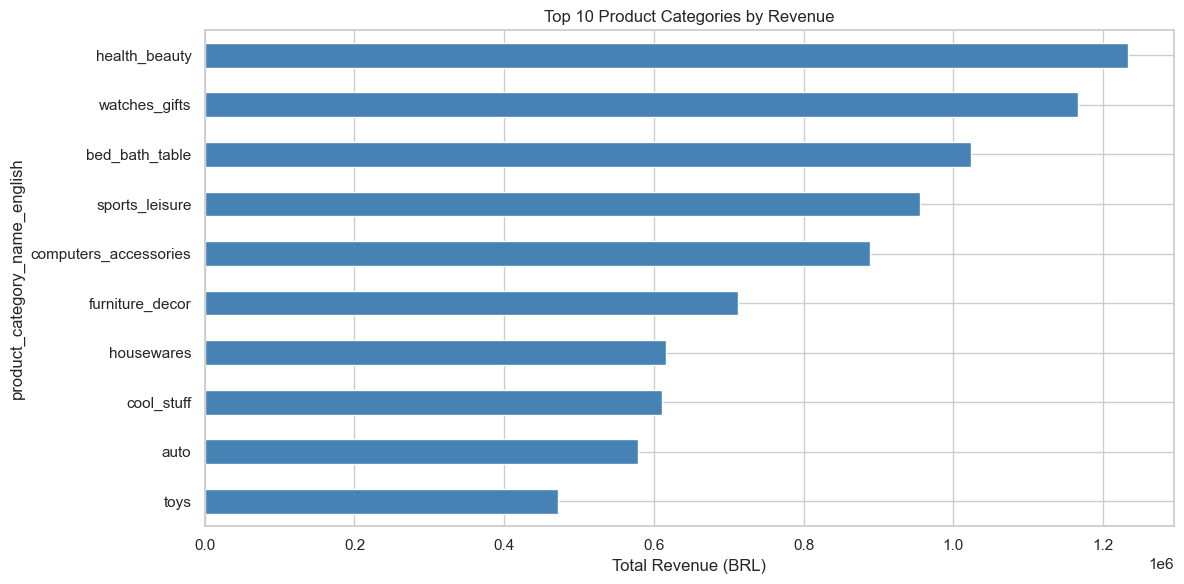

In [15]:
top_cats = (df2.groupby('product_category_name_english')['price']
               .sum()
               .sort_values(ascending=False)
               .head(10))

plt.figure(figsize=(12, 6))
top_cats.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150)
plt.show()

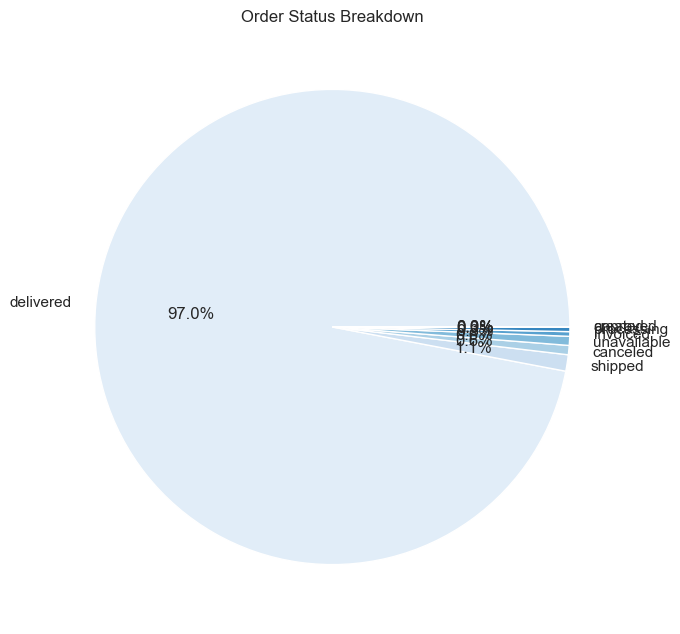

In [17]:
status_counts = orders['order_status'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Blues', len(status_counts)))
plt.title('Order Status Breakdown')
plt.tight_layout()
plt.savefig('order_status.png', dpi=150)
plt.show()

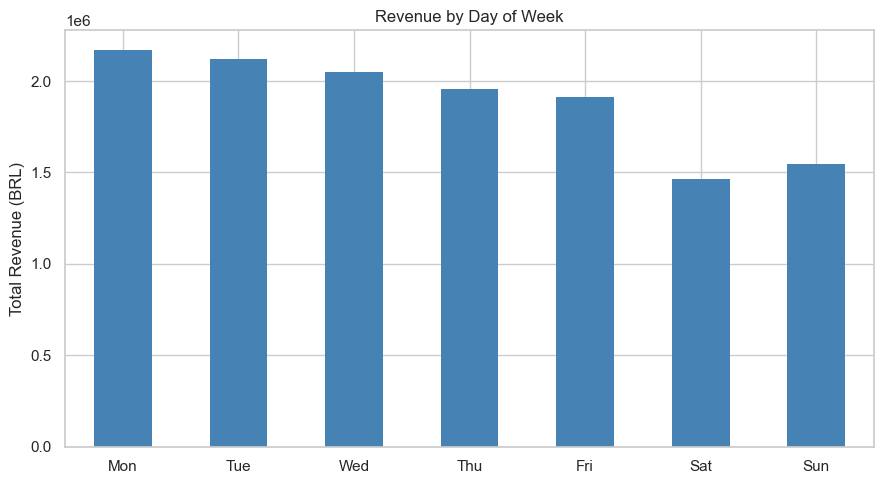

In [18]:
df['day_of_week'] = df['order_purchase_timestamp'].dt.strftime('%a')
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

day_rev = df.groupby('day_of_week')['price'].sum().reindex(day_order)

plt.figure(figsize=(9, 5))
day_rev.plot(kind='bar', color='steelblue', edgecolor='none')
plt.title('Revenue by Day of Week')
plt.ylabel('Total Revenue (BRL)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('revenue_by_day.png', dpi=150)
plt.show()

In [19]:
total_revenue   = df['price'].sum()
total_orders    = df['order_id'].nunique()
avg_order_value = total_revenue / total_orders
total_customers = df['customer_id'].nunique()

print("=" * 40)
print(f"  Total Revenue    : R$ {total_revenue:,.2f}")
print(f"  Total Orders     : {total_orders:,}")
print(f"  Avg Order Value  : R$ {avg_order_value:,.2f}")
print(f"  Unique Customers : {total_customers:,}")
print("=" * 40)

  Total Revenue    : R$ 13,221,498.11
  Total Orders     : 96,478
  Avg Order Value  : R$ 137.04
  Unique Customers : 96,478


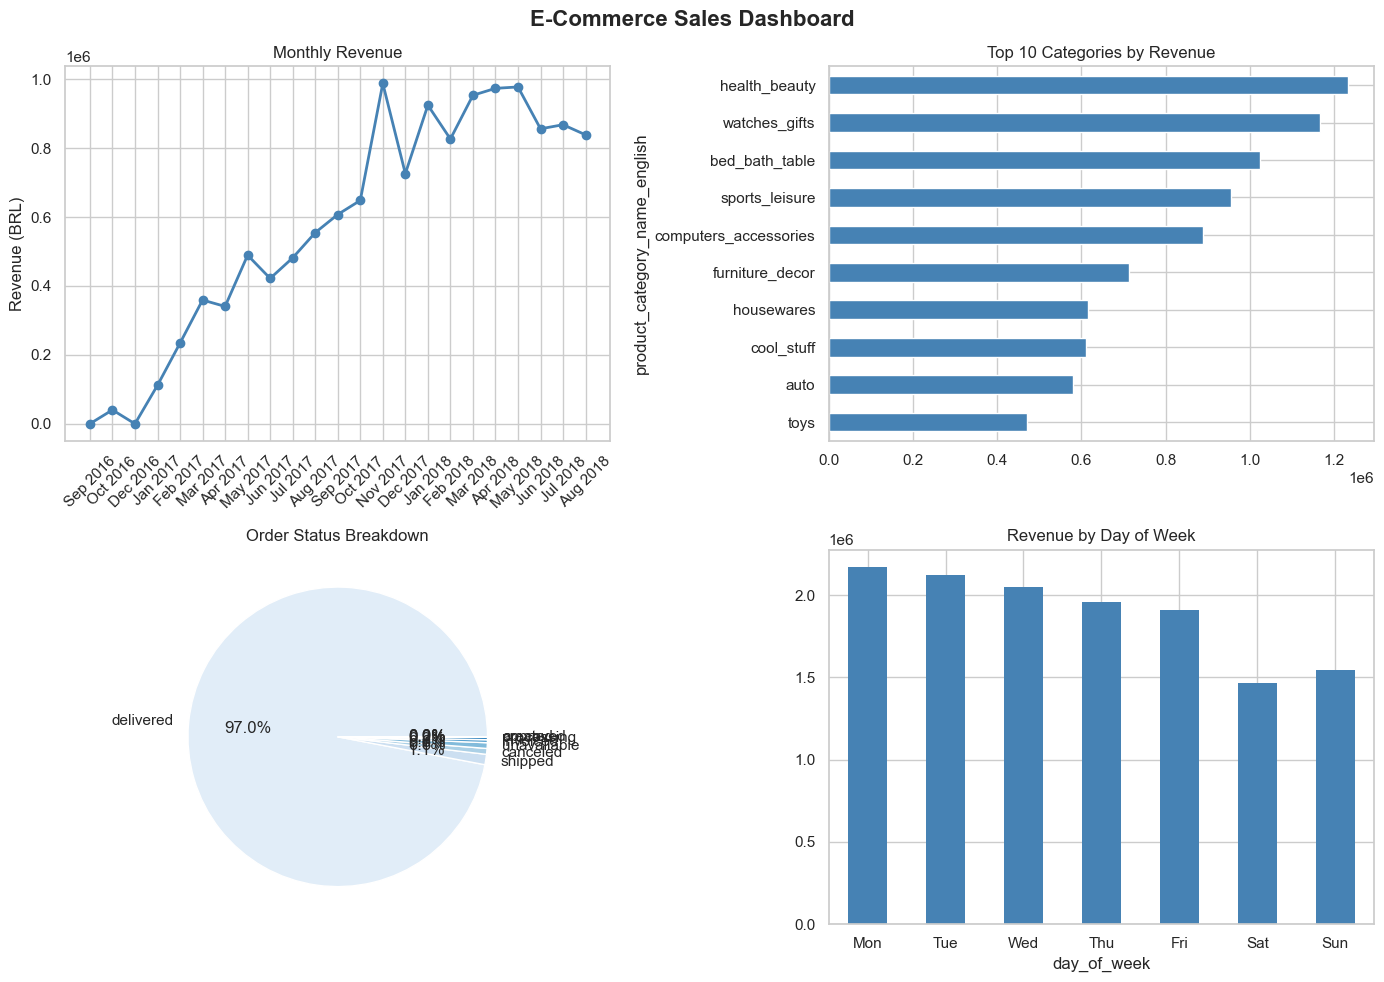

Dashboard saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('E-Commerce Sales Dashboard', fontsize=16, fontweight='bold')

# Chart 1 - Monthly revenue
monthly_rev = df.groupby('month_name')['price'].sum().reset_index()
monthly_rev['order_date'] = pd.to_datetime(monthly_rev['month_name'], format='%b %Y')
monthly_rev = monthly_rev.sort_values('order_date')
axes[0,0].plot(monthly_rev['month_name'], monthly_rev['price'], marker='o', color='steelblue', linewidth=2)
axes[0,0].set_title('Monthly Revenue')
axes[0,0].set_ylabel('Revenue (BRL)')
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2 - Top categories
top_cats = (df2.groupby('product_category_name_english')['price']
               .sum().sort_values(ascending=False).head(10))
top_cats.sort_values().plot(kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Top 10 Categories by Revenue')

# Chart 3 - Order status
status_counts = orders['order_status'].value_counts()
axes[1,0].pie(status_counts, labels=status_counts.index,
              autopct='%1.1f%%', colors=sns.color_palette('Blues', len(status_counts)))
axes[1,0].set_title('Order Status Breakdown')

# Chart 4 - Revenue by day
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['day_of_week'] = df['order_purchase_timestamp'].dt.strftime('%a')
day_rev = df.groupby('day_of_week')['price'].sum().reindex(day_order)
day_rev.plot(kind='bar', ax=axes[1,1], color='steelblue', edgecolor='none')
axes[1,1].set_title('Revenue by Day of Week')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150)
plt.show()
print("Dashboard saved!")

## 💡 Key Business Insights

| Metric | Value |
|--------|-------|
| Total Revenue | R$ 13,221,498 |
| Total Orders | 96,478 |
| Avg Order Value | R$ 137.04 |
| Unique Customers | 96,478 |

**Findings:**
- Revenue grew steadily through 2017, peaking in November (likely Black Friday)
- Health & Beauty and Watches & Gifts were top revenue categories
- 97% of orders were successfully delivered
- Weekdays drive significantly more revenue than weekends
- Every customer ordered exactly once — repeat purchase rate is 0%